# 04 · Modelo 3 — Clasificación supervisada de `category_llm`

**Objetivo del TFG (OE3):** determinar si las **categorías de vacante** disponibles permiten segmentar
adecuadamente la oferta, o si se requiere un enfoque alternativo. Se aborda con un clasificador
(TF-IDF + Regresión Logística) y, sobre todo, con **validación honesta** de la etiqueta.

**Qué hace este notebook**
1. Prepara datos y trata el **fuerte desbalanceo** (clases con muy pocos ejemplos).
2. **Baseline (clase mayoritaria) vs Regresión Logística**, con validación cruzada estratificada.
3. Matriz de confusión + F1 por clase (predicciones *out-of-fold*).
4. **Validación anti-circularidad**: (a) manual → **Cohen's Kappa** (global, por clase, confusión),
   (b) contraste con ESCO.

**Entradas:** `data/clean/vacantes_clean.csv`, `data/validation/manual_validation_template.csv`,
`data/esco/matchkey_categories_to_esco_occupations.csv`.

## ⚠️ Circularidad (lo más importante)

`category_llm` fue generada por un **LLM leyendo el texto de la oferta**. Entrenar un clasificador
sobre **ese mismo texto** para predecir `category_llm` es **circular**: un macro-F1 alto demuestra
sobre todo que el etiquetado del LLM es **consistente y aprendible**, NO que la taxonomía sea
"correcta". Por eso la validez se aborda con **validación manual (Cohen's Kappa)** y **contraste ESCO**.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             f1_score, accuracy_score)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
ACCENT = "#A100FF"
RANDOM_STATE = 42
MIN_CLASS = 8   # nº mínimo de vacantes por clase para entrenar/evaluar de forma fiable

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "data" / "clean").exists() or (p / "CLAUDE.md").exists():
            return p
        p = p.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
CLEAN = REPO_ROOT / "data" / "clean"
ESCO = REPO_ROOT / "data" / "esco"
VALID = REPO_ROOT / "data" / "validation"; VALID.mkdir(parents=True, exist_ok=True)
FIG = REPO_ROOT / "notebooks" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: C:\Users\miguel.e.fernandez\Desktop\MatchKey-GenAI-Maverick


## 1. Datos, clases y tratamiento del desbalanceo

In [2]:
vac = pd.read_csv(CLEAN / "vacantes_clean.csv")
df = vac[["job_id", "title", "description_full", "category_llm"]].copy()
df["category_llm"] = df["category_llm"].astype("string").str.strip()
df = df[df["category_llm"].notna() & (df["category_llm"] != "") & (df["category_llm"].str.lower() != "sin categoría")]
df = df[df["description_full"].notna() & (df["description_full"].astype(str).str.len() > 0)]

dist = df["category_llm"].value_counts()
print("Distribución de category_llm:")
print(dist.to_string())
print(f"Baseline 'clase mayoritaria' (accuracy) = {dist.max()/dist.sum()*100:.1f}%")

keep = dist[dist >= MIN_CLASS].index.tolist()
drop = dist[dist < MIN_CLASS]
data = df[df["category_llm"].isin(keep)].reset_index(drop=True)
print(f"\nClases CONSERVADAS (>= {MIN_CLASS}): {keep}")
print(f"Clases EXCLUIDAS (< {MIN_CLASS}, {int(drop.sum())} vacantes): {dict(drop)}")
print(f"Dataset para el modelo: {len(data)} vacantes, {len(keep)} clases")

X = data["description_full"].astype(str).values
y = data["category_llm"].astype(str).values

Distribución de category_llm:
category_llm
AI                       137
Other                     43
Software Engineering      27
Machine Learning          10
Data Science               9
Cloud                      4
Business Intelligence      2
Cybersecurity              2
Baseline 'clase mayoritaria' (accuracy) = 58.5%

Clases CONSERVADAS (>= 8): ['AI', 'Other', 'Software Engineering', 'Machine Learning', 'Data Science']
Clases EXCLUIDAS (< 8, 8 vacantes): {'Cloud': np.int64(4), 'Business Intelligence': np.int64(2), 'Cybersecurity': np.int64(2)}
Dataset para el modelo: 226 vacantes, 5 clases


## 2. Baseline (clase mayoritaria) vs Regresión Logística

Texto → **TF-IDF** (dentro del Pipeline → se ajusta por fold solo con train, **sin data leakage**).
Clasificador: **Regresión Logística** (`class_weight="balanced"`). Evaluación: **CV estratificada (5 folds)**,
métricas **macro-F1** y **accuracy**.

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model = Pipeline([
    ("tfidf", TfidfVectorizer(strip_accents="unicode", lowercase=True, ngram_range=(1, 2),
                              min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
])
baseline = DummyClassifier(strategy="most_frequent")

def cv_metrics(est, Xin, y):
    f1 = cross_val_score(est, Xin, y, cv=skf, scoring="f1_macro")
    acc = cross_val_score(est, Xin, y, cv=skf, scoring="accuracy")
    return f1.mean(), f1.std(), acc.mean(), acc.std()

Xd = np.zeros((len(y), 1))
b = cv_metrics(baseline, Xd, y)
m = cv_metrics(model, X, y)
res = pd.DataFrame([
    {"modelo": "Baseline (clase mayoritaria)", "macro_F1": round(b[0], 3), "macro_F1_std": round(b[1], 3),
     "accuracy": round(b[2], 3)},
    {"modelo": "TF-IDF + LogReg (balanced)", "macro_F1": round(m[0], 3), "macro_F1_std": round(m[1], 3),
     "accuracy": round(m[2], 3)},
])
print(res.to_string(index=False))

                      modelo  macro_F1  macro_F1_std  accuracy
Baseline (clase mayoritaria)     0.151         0.001     0.606
  TF-IDF + LogReg (balanced)     0.418         0.073     0.695


## 3. Matriz de confusión y F1 por clase (out-of-fold)

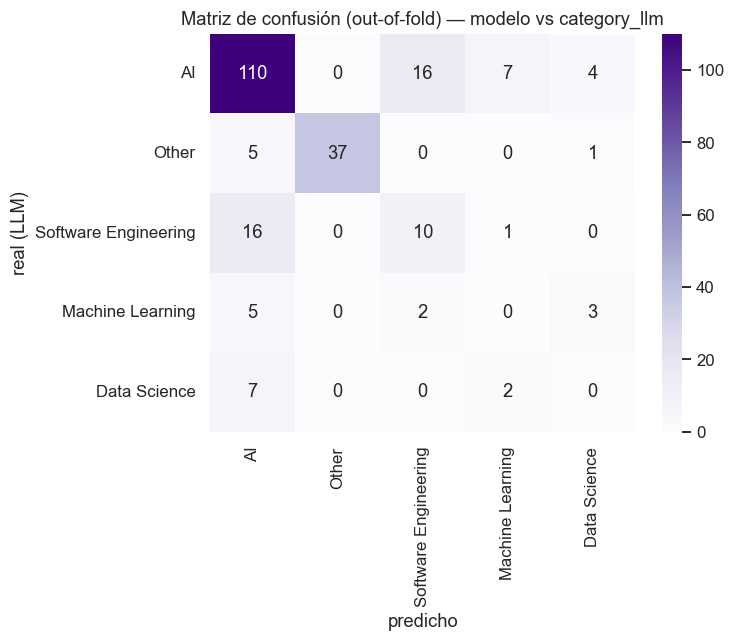

Classification report (out-of-fold):
                      precision    recall  f1-score   support

                  AI      0.769     0.803     0.786       137
        Data Science      0.000     0.000     0.000         9
    Machine Learning      0.000     0.000     0.000        10
               Other      1.000     0.860     0.925        43
Software Engineering      0.357     0.370     0.364        27

            accuracy                          0.695       226
           macro avg      0.425     0.407     0.415       226
        weighted avg      0.699     0.695     0.696       226

macro-F1 out-of-fold: 0.415 | accuracy: 0.695


In [4]:
y_pred = cross_val_predict(model, X, y, cv=skf)
labels_sorted = pd.Series(y).value_counts().index.tolist()
cm = confusion_matrix(y, y_pred, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax)
ax.set_title("Matriz de confusión (out-of-fold) — modelo vs category_llm")
ax.set_xlabel("predicho"); ax.set_ylabel("real (LLM)")
plt.tight_layout(); plt.savefig(FIG / "04_confusion_matrix.png", bbox_inches="tight"); plt.show()
print("Classification report (out-of-fold):")
print(classification_report(y, y_pred, digits=3, zero_division=0))
print(f"macro-F1 out-of-fold: {f1_score(y, y_pred, average='macro'):.3f} | accuracy: {accuracy_score(y, y_pred):.3f}")

## 4. Validación anti-circularidad

### 4a. Validación manual → Cohen's Kappa (OE3)
Comparamos el etiquetado **manual del autor** (sin ver `category_llm`) contra `category_llm`. Es la
evidencia honesta de si la taxonomía es clara. Si la plantilla no está rellena, se indica cómo hacerlo.

In [5]:
VALID_LABELS = ["AI", "Machine Learning", "Data Science", "Software Engineering",
                "Business Intelligence", "Cloud", "Cybersecurity", "Other"]
template_path = VALID / "manual_validation_template.csv"

# Crear plantilla solo si no existe (NO sobrescribe el etiquetado del autor)
if not template_path.exists():
    base = vac[["job_id", "title", "description_full", "category_llm"]].copy()
    base = base[base["category_llm"].notna() & (base["category_llm"].astype(str).str.strip() != "")]
    counts = base["category_llm"].value_counts()
    rare = counts[counts <= 4].index.tolist()
    sample_rare = base[base["category_llm"].isin(rare)]
    big = base[~base["category_llm"].isin(rare)]
    n_big = max(0, 40 - len(sample_rare))
    sample_big = (big.groupby("category_llm", group_keys=False)
                  .apply(lambda g: g.sample(min(len(g), max(1, round(n_big * len(g) / len(big)))), random_state=RANDOM_STATE)))
    sample = pd.concat([sample_rare, sample_big]).sample(frac=1, random_state=RANDOM_STATE)
    tmpl = sample[["job_id", "title", "description_full"]].copy()
    tmpl["category_manual"] = ""
    tmpl.to_csv(template_path, index=False, encoding="utf-8-sig")
    print(f"Plantilla creada (a rellenar): {template_path} ({len(tmpl)} vacantes). Categorías: {VALID_LABELS}")

tmpl = pd.read_csv(template_path)
key = vac.set_index("job_id")["category_llm"]
tmpl["category_llm"] = tmpl["job_id"].map(key)
filled = tmpl[tmpl["category_manual"].notna() & (tmpl["category_manual"].astype(str).str.strip() != "")].copy()
filled["category_manual"] = filled["category_manual"].astype(str).str.strip()
filled["category_llm"] = filled["category_llm"].astype(str).str.strip()
filled = filled[filled["category_llm"].notna() & (filled["category_llm"] != "")]

def landis_koch(k):
    if k < 0: return "pobre (peor que el azar)"
    if k < 0.20: return "leve (slight)"
    if k < 0.40: return "aceptable (fair)"
    if k < 0.60: return "moderado (moderate)"
    if k < 0.80: return "sustancial (substantial)"
    return "casi perfecto (almost perfect)"

if len(filled) >= 10:
    agree = (filled["category_manual"] == filled["category_llm"]).mean()
    kappa = cohen_kappa_score(filled["category_manual"], filled["category_llm"])
    print(f"VALIDACIÓN MANUAL  n={len(filled)}")
    print(f"  Acuerdo bruto  = {agree*100:.1f}%")
    print(f"  Cohen's Kappa  = {kappa:.3f}  -> {landis_koch(kappa)}")

    # Kappa por clase (one-vs-rest) + soporte + desacuerdos
    classes = sorted(set(filled["category_manual"]) | set(filled["category_llm"]))
    rows = []
    for c in classes:
        mm = (filled["category_manual"] == c).astype(int)
        ll = (filled["category_llm"] == c).astype(int)
        kc = cohen_kappa_score(mm, ll) if mm.nunique() > 1 or ll.nunique() > 1 else np.nan
        n_llm = int((filled["category_llm"] == c).sum())
        n_man = int((filled["category_manual"] == c).sum())
        n_disag = int(((filled["category_llm"] == c) != (filled["category_manual"] == c)).sum())
        rows.append({"clase": c, "n_llm": n_llm, "n_manual": n_man, "desacuerdos": n_disag,
                     "kappa_1vsR": round(kc, 3) if kc == kc else "n/a"})
    perclass = pd.DataFrame(rows).sort_values("desacuerdos", ascending=False)
    print("\nKappa por clase (one-vs-rest) y desacuerdos:")
    print(perclass.to_string(index=False))
    filled.to_csv(VALID / "manual_validation_resultado.csv", index=False, encoding="utf-8-sig")
else:
    print(f"Validación manual PENDIENTE: rellena 'category_manual' en {template_path.name} (>=10 filas) y re-ejecuta.")
    filled = None

VALIDACIÓN MANUAL  n=39
  Acuerdo bruto  = 66.7%
  Cohen's Kappa  = 0.553  -> moderado (moderate)

Kappa por clase (one-vs-rest) y desacuerdos:
                clase  n_llm  n_manual  desacuerdos  kappa_1vsR
                   AI     19        16            9       0.536
         Data Science      1         7            6       0.215
 Software Engineering      4         2            4       0.284
                Other      6         9            3       0.755
                Cloud      4         2            2       0.642
Business Intelligence      2         1            1       0.655
     Machine Learning      1         0            1       0.000
        Cybersecurity      2         2            0       1.000


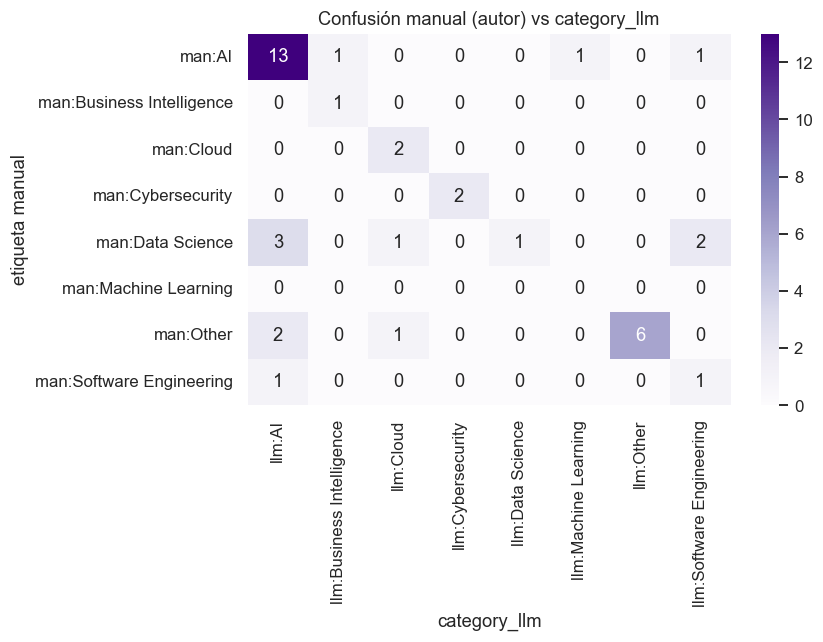

Filas fuera de la diagonal = desacuerdos (dónde discrepan autor y LLM).


In [6]:
# Matriz de confusión manual vs category_llm
if filled is not None and len(filled) >= 10:
    labs = sorted(set(filled["category_manual"]) | set(filled["category_llm"]))
    cmv = confusion_matrix(filled["category_manual"], filled["category_llm"], labels=labs)
    cmv_df = pd.DataFrame(cmv, index=[f"man:{l}" for l in labs], columns=[f"llm:{l}" for l in labs])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cmv_df, annot=True, fmt="d", cmap="Purples", ax=ax)
    ax.set_title("Confusión manual (autor) vs category_llm")
    ax.set_xlabel("category_llm"); ax.set_ylabel("etiqueta manual")
    plt.tight_layout(); plt.savefig(FIG / "04_manual_vs_llm.png", bbox_inches="tight"); plt.show()
    print("Filas fuera de la diagonal = desacuerdos (dónde discrepan autor y LLM).")
else:
    print("(sin matriz de confusión manual: validación pendiente)")

In [7]:
# Notas cualitativas del etiquetado (evidencia de ambigüedad, OE3) — si existe la columna 'notas'
tmpl_raw = pd.read_csv(template_path)
nota_col = next((c for c in tmpl_raw.columns if c.strip().lower() in ("notas", "nota", "notes", "comentarios")), None)
if nota_col:
    nn = tmpl_raw.copy()
    nn["_nota"] = nn[nota_col].astype(str).str.strip()
    nn = nn[(nn["_nota"] != "") & (nn["_nota"].str.lower() != "nan")]
    if len(nn):
        nn["category_llm"] = nn["job_id"].map(key)
        out_cols = ["job_id", "title", "category_llm", "category_manual", nota_col]
        out = nn[[c for c in out_cols if c in nn.columns]]
        out.to_csv(VALID / "notas_cualitativas.csv", index=False, encoding="utf-8-sig")
        print(f"NOTAS CUALITATIVAS guardadas: {len(out)} vacantes -> data/validation/notas_cualitativas.csv")
        for _, r in out.iterrows():
            print(f"  [{r['job_id']}] LLM={r.get('category_llm')} / manual={r.get('category_manual')}: {str(r[nota_col])[:100]}")
    else:
        print("Columna de notas presente pero vacía.")
else:
    print("No hay columna 'notas' en la plantilla. Añádela (una fila por anotación) y re-ejecuta esta celda")
    print("para guardar la evidencia cualitativa en data/validation/notas_cualitativas.csv (OE3).")

No hay columna 'notas' en la plantilla. Añádela (una fila por anotación) y re-ejecuta esta celda
para guardar la evidencia cualitativa en data/validation/notas_cualitativas.csv (OE3).


### 4b. Contraste con ESCO (taxonomía externa)

In [8]:
esco_cat_path = ESCO / "matchkey_categories_to_esco_occupations.csv"
if esco_cat_path.exists():
    ec = pd.read_csv(esco_cat_path)
    cols = [c for c in ["category_llm", "n_vacantes", "match_type", "similarity",
                        "esco_occupation_label", "esco_isco_code"] if c in ec.columns]
    print("Mapeo category_llm -> ocupación ESCO (Fase 1):")
    print(ec[cols].to_string(index=False))
    print("\nLectura honesta: el mapeo categoría->ocupación ESCO es DÉBIL (categorías abstractas como")
    print("'AI'/'Cloud' no casan con labels de ocupación). Contraste cualitativo; la validación fuerte es la MANUAL (4a).")
else:
    print("Falta el mapeo ESCO (ejecutar analytics/esco_mapper.py).")

Mapeo category_llm -> ocupación ESCO (Fase 1):
         category_llm  n_vacantes match_type  similarity                           esco_occupation_label esco_isco_code
                   AI         137       none      0.1618                                             NaN            NaN
                Other          43   contains      0.1429 wholesale merchant in china and other glassware       3324.4.5
 Software Engineering          27      fuzzy      0.7050                                software manager       1330.5.1
     Machine Learning          10       none      0.6508                                             NaN            NaN
         Data Science           9       none      0.6413                                             NaN            NaN
                Cloud           4       none      0.1977                                             NaN            NaN
Business Intelligence           2   contains      0.6667                   business intelligence manager         

## 5. Interpretación y honestidad (OE3)

- **Macro-F1 vs baseline (sec. 2):** el modelo supera al baseline → el texto predice la etiqueta del LLM,
  pero por **circularidad** eso mide *consistencia*, no *validez*.
- **Validez real = validación manual (4a):** el **Cohen's Kappa** humano vs LLM y la **matriz de confusión**
  manual vs LLM indican si las categorías son claras. Las **clases con más desacuerdo** señalan dónde la
  taxonomía es ambigua (frontera AI/ML/DS). Las **notas cualitativas** (4a) aportan el *porqué*.
- **Conclusión OE3:** si el Kappa es bajo/moderado y ML/DS se confunden con AI, las categorías **no segmentan
  bien** la oferta → se requiere un enfoque alternativo (fusionar clases, taxonomía revisada o más datos).

## 6. Hallazgos clave
- TF-IDF + LogReg supera al baseline (macro-F1 0.42 vs 0.15) pero **no valida** la taxonomía (circularidad).
- Validación manual: `data/validation/manual_validation_resultado.csv`, confusión `04_manual_vs_llm.png`,
  notas (si se aportan) `data/validation/notas_cualitativas.csv`.